In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [5]:
df=pd.read_csv("ecommerce_sales_dataset.csv")
df

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,revenue,profit,payment_method,delivery_days,order_status
0,ORD100001,2025-02-02,CUST1156,Desk Lamp,Furniture,East,1,40,0.10,36.00,9.22,UPI,10,Completed
1,ORD100002,2025-10-10,CUST1205,Monitor,Electronics,East,3,210,0.10,567.00,116.53,UPI,2,Completed
2,ORD100003,2025-08-27,CUST1078,Smartphone Case,Mobile,North,4,18,0.00,72.00,8.30,UPI,7,Shipped
3,ORD100004,2025-06-10,CUST1061,Office Chair,Furniture,North,3,180,0.10,486.00,118.48,UPI,9,Completed
4,ORD100005,2025-06-08,CUST1188,Headphones,Electronics,East,2,90,0.10,162.00,10.28,Debit Card,9,Shipped
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD101196,2025-08-20,CUST1245,Headphones,Electronics,South,2,90,0.10,162.00,29.85,Debit Card,8,Completed
1196,ORD101197,2025-09-18,CUST1019,Smartphone Case,Mobile,East,2,18,0.10,32.40,1.01,UPI,9,Completed
1197,ORD101198,2025-12-25,CUST1259,Mechanical Keyboard,Accessories,North,3,75,0.05,213.75,58.57,Cash on Delivery,10,Cancelled
1198,ORD101199,2025-10-21,CUST1108,Mechanical Keyboard,Accessories,North,2,75,0.20,120.00,9.14,Credit Card,9,Pending


In [6]:
#Data Profiling
df.shape

(1200, 14)

In [7]:
df.size


16800

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        1200 non-null   object 
 1   order_date      1200 non-null   object 
 2   customer_id     1200 non-null   object 
 3   product         1200 non-null   object 
 4   category        1200 non-null   object 
 5   region          1200 non-null   object 
 6   quantity        1200 non-null   int64  
 7   unit_price      1200 non-null   int64  
 8   discount        1200 non-null   float64
 9   revenue         1200 non-null   float64
 10  profit          1200 non-null   float64
 11  payment_method  1200 non-null   object 
 12  delivery_days   1200 non-null   int64  
 13  order_status    1200 non-null   object 
dtypes: float64(3), int64(3), object(8)
memory usage: 131.4+ KB


In [9]:
df.describe()

,quantity,unit_price,discount,revenue,profit,delivery_days
count,"1,200.00","1,200.00","1,200.00","1,200.00","1,200.00","1,200.00"
mean,2.99,78.17,0.08,213.21,36.56,5.58
std,1.42,63.35,0.06,216.89,46.60,2.88
min,1.00,18.00,0.00,14.40,-8.92,1.00
25%,2.00,35.00,0.05,70.40,7.48,3.00
50%,3.00,45.00,0.10,140.00,19.64,6.00
75%,4.00,90.00,0.10,260.00,44.50,8.00
max,5.00,210.00,0.20,"1,050.00",294.78,10.00


In [26]:
df.sample(5, random_state=42)

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,revenue,profit,payment_method,delivery_days,order_status,calculated_revenue,revenue_difference
1178,ORD101179,2025-04-05,CUST1287,Smartphone Case,Mobile,South,5,18,0.10,81.00,14.87,UPI,6,Completed,89.91,0.00
865,ORD100866,2025-09-12,CUST1100,Webcam,Electronics,North,4,65,0.15,221.00,26.66,UPI,10,Completed,259.61,0.00
101,ORD100102,2025-03-14,CUST1002,Monitor,Electronics,East,1,210,0.00,210.00,23.79,Debit Card,6,Cancelled,210.00,0.00
439,ORD100440,2025-05-26,CUST1021,Mechanical Keyboard,Accessories,East,5,75,0.10,337.50,70.88,Net Banking,7,Pending,374.62,0.00
58,ORD100059,2025-09-29,CUST1045,Webcam,Electronics,South,3,65,0.05,185.25,12.93,Cash on Delivery,6,Shipped,194.90,0.00


In [10]:
#Clean The Dataset
print(df.isnull())
df.isna().sum()

      order_id  order_date  customer_id  product  category  region  quantity  \
0        False       False        False    False     False   False     False   
1        False       False        False    False     False   False     False   
2        False       False        False    False     False   False     False   
3        False       False        False    False     False   False     False   
4        False       False        False    False     False   False     False   
...        ...         ...          ...      ...       ...     ...       ...   
1195     False       False        False    False     False   False     False   
1196     False       False        False    False     False   False     False   
1197     False       False        False    False     False   False     False   
1198     False       False        False    False     False   False     False   
1199     False       False        False    False     False   False     False   

      unit_price  discount  revenue  pr

,0
order_id,0
order_date,0
customer_id,0
product,0
category,0
region,0
quantity,0
unit_price,0
discount,0
revenue,0


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1195,False
1196,False
1197,False
1198,False


In [59]:
#convert the incorrect data types into the appropriate ones
df["order_date"] = pd.to_datetime(df["order_date"])
df

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,revenue,profit,payment_method,delivery_days,order_status,calculated_revenue,revenue_difference
0,ORD100001,2025-02-02,CUST1156,Desk Lamp,Furniture,East,1,40,0.10,36.00,9.22,UPI,10,Completed,36.00,0.00
1,ORD100002,2025-10-10,CUST1205,Monitor,Electronics,East,3,210,0.10,567.00,116.53,UPI,2,Completed,567.00,0.00
2,ORD100003,2025-08-27,CUST1078,Smartphone Case,Mobile,North,4,18,0.00,72.00,8.30,UPI,7,Shipped,72.00,0.00
3,ORD100004,2025-06-10,CUST1061,Office Chair,Furniture,North,3,180,0.10,486.00,118.48,UPI,9,Completed,486.00,0.00
4,ORD100005,2025-06-08,CUST1188,Headphones,Electronics,East,2,90,0.10,162.00,10.28,Debit Card,9,Shipped,162.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD101196,2025-08-20,CUST1245,Headphones,Electronics,South,2,90,0.10,162.00,29.85,Debit Card,8,Completed,162.00,0.00
1196,ORD101197,2025-09-18,CUST1019,Smartphone Case,Mobile,East,2,18,0.10,32.40,1.01,UPI,9,Completed,32.40,0.00
1197,ORD101198,2025-12-25,CUST1259,Mechanical Keyboard,Accessories,North,3,75,0.05,213.75,58.57,Cash on Delivery,10,Cancelled,213.75,0.00
1198,ORD101199,2025-10-21,CUST1108,Mechanical Keyboard,Accessories,North,2,75,0.20,120.00,9.14,Credit Card,9,Pending,120.00,0.00


In [61]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()
df["quarter"] = df["order_date"].dt.quarter
df["day_name"] = df["order_date"].dt.day_name()

In [62]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]
df["month_name"] = pd.Categorical(
    df["month_name"],
    categories=month_order,
    ordered=True
)


In [63]:
df

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,revenue,profit,payment_method,delivery_days,order_status,calculated_revenue,revenue_difference,year,month,month_name,quarter,day_name
0,ORD100001,2025-02-02,CUST1156,Desk Lamp,Furniture,East,1,40,0.10,36.00,9.22,UPI,10,Completed,36.00,0.00,2025,2,February,1,Sunday
1,ORD100002,2025-10-10,CUST1205,Monitor,Electronics,East,3,210,0.10,567.00,116.53,UPI,2,Completed,567.00,0.00,2025,10,October,4,Friday
2,ORD100003,2025-08-27,CUST1078,Smartphone Case,Mobile,North,4,18,0.00,72.00,8.30,UPI,7,Shipped,72.00,0.00,2025,8,August,3,Wednesday
3,ORD100004,2025-06-10,CUST1061,Office Chair,Furniture,North,3,180,0.10,486.00,118.48,UPI,9,Completed,486.00,0.00,2025,6,June,2,Tuesday
4,ORD100005,2025-06-08,CUST1188,Headphones,Electronics,East,2,90,0.10,162.00,10.28,Debit Card,9,Shipped,162.00,0.00,2025,6,June,2,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD101196,2025-08-20,CUST1245,Headphones,Electronics,South,2,90,0.10,162.00,29.85,Debit Card,8,Completed,162.00,0.00,2025,8,August,3,Wednesday
1196,ORD101197,2025-09-18,CUST1019,Smartphone Case,Mobile,East,2,18,0.10,32.40,1.01,UPI,9,Completed,32.40,0.00,2025,9,September,3,Thursday
1197,ORD101198,2025-12-25,CUST1259,Mechanical Keyboard,Accessories,North,3,75,0.05,213.75,58.57,Cash on Delivery,10,Cancelled,213.75,0.00,2025,12,December,4,Thursday
1198,ORD101199,2025-10-21,CUST1108,Mechanical Keyboard,Accessories,North,2,75,0.20,120.00,9.14,Credit Card,9,Pending,120.00,0.00,2025,10,October,4,Tuesday


In [ ]:
df["month"] = df["order_date"].dt.to_period("M").astype(str)
df["profit_margin"] = df["profit"] / df["revenue"] * 100

In [23]:
df

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,revenue,profit,payment_method,delivery_days,order_status,calculated_revenue,revenue_difference
0,ORD100001,2025-02-02,CUST1156,Desk Lamp,Furniture,East,1,40,0.10,36.00,9.22,UPI,10,Completed,36.00,0.00
1,ORD100002,2025-10-10,CUST1205,Monitor,Electronics,East,3,210,0.10,567.00,116.53,UPI,2,Completed,567.00,0.00
2,ORD100003,2025-08-27,CUST1078,Smartphone Case,Mobile,North,4,18,0.00,72.00,8.30,UPI,7,Shipped,72.00,0.00
3,ORD100004,2025-06-10,CUST1061,Office Chair,Furniture,North,3,180,0.10,486.00,118.48,UPI,9,Completed,486.00,0.00
4,ORD100005,2025-06-08,CUST1188,Headphones,Electronics,East,2,90,0.10,162.00,10.28,Debit Card,9,Shipped,162.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD101196,2025-08-20,CUST1245,Headphones,Electronics,South,2,90,0.10,162.00,29.85,Debit Card,8,Completed,162.00,0.00
1196,ORD101197,2025-09-18,CUST1019,Smartphone Case,Mobile,East,2,18,0.10,32.40,1.01,UPI,9,Completed,32.40,0.00
1197,ORD101198,2025-12-25,CUST1259,Mechanical Keyboard,Accessories,North,3,75,0.05,213.75,58.57,Cash on Delivery,10,Cancelled,213.75,0.00
1198,ORD101199,2025-10-21,CUST1108,Mechanical Keyboard,Accessories,North,2,75,0.20,120.00,9.14,Credit Card,9,Pending,120.00,0.00


In [27]:
#counts for Categorical Value
categorical_columns = [
    "product",
    "category",
    "region",
    "payment_method",
    "order_status"
]

for column in categorical_columns:
    print(f"\n{column.upper()}")
    print(df[column].value_counts())


PRODUCT
product
Wireless Mouse         129
Mechanical Keyboard    126
Office Chair           124
USB-C Hub              124
Smartphone Case        123
Monitor                122
Desk Lamp              116
Laptop Stand           114
Webcam                 113
Headphones             109
Name: count, dtype: int64

CATEGORY
category
Accessories    493
Electronics    344
Furniture      240
Mobile         123
Name: count, dtype: int64

REGION
region
North      266
East       239
South      234
Central    233
West       228
Name: count, dtype: int64

PAYMENT_METHOD
payment_method
UPI                 402
Credit Card         322
Debit Card          216
Cash on Delivery    138
Net Banking         122
Name: count, dtype: int64

ORDER_STATUS
order_status
Completed    690
Pending      183
Shipped      168
Cancelled    159
Name: count, dtype: int64


In [33]:
total_revenue = df["revenue"].sum()
total_profit = df["profit"].sum()
total_orders = df["order_id"].nunique()
total_units = df["quantity"].sum()
average_order_value = total_revenue / total_orders
profit_margin = total_profit / total_revenue * 100
return_rate = (df["order_status"] == "Returned").mean() * 100

print("Total revenue:", total_revenue)
print("Total profit:", total_profit)
print("Total orders:", total_orders)
print("Total units:", total_units)
print("Average order value:", average_order_value)
print("Profit margin:", profit_margin)
print("Return rate:", return_rate)

Total revenue: 255856.75
Total profit: 43871.75
Total orders: 1200
Total units: 3592
Average order value: 213.21395833333332
Profit margin: 17.146997294384455
Return rate: 0.0


In [34]:
#Calculate revenue independently
df["calculated_revenue"] = (
    df["quantity"] *
    df["unit_price"] *
    (1 - df["discount"])
)
print(df['calculated_revenue'])

0       36.00
1      567.00
2       72.00
3      486.00
4      162.00
        ...  
1195   162.00
1196    32.40
1197   213.75
1198   120.00
1199   720.00
Name: calculated_revenue, Length: 1200, dtype: float64


In [35]:
df["revenue_difference"] = (
    df["revenue"] - df["calculated_revenue"]
).round(2)

print(df["revenue_difference"])

0      0.00
1      0.00
2      0.00
3      0.00
4      0.00
       ... 
1195   0.00
1196   0.00
1197   0.00
1198   0.00
1199   0.00
Name: revenue_difference, Length: 1200, dtype: float64


/tmp/ipykernel_1692/627360465.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


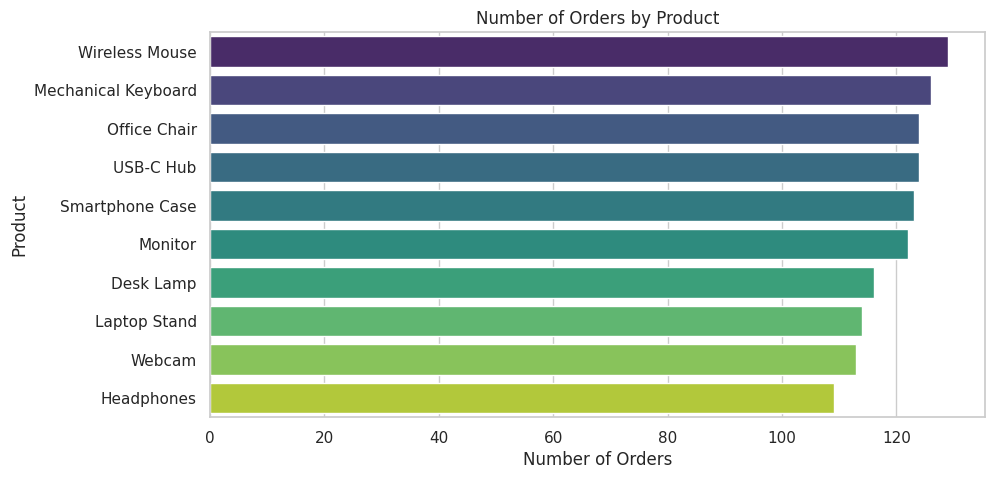

In [44]:
#Univariate analysis
#1.Product distribution
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    y="product",
    order=df["product"].value_counts().index,
    palette="viridis"
)

plt.title("Number of Orders by Product")
plt.xlabel("Number of Orders")
plt.ylabel("Product")
plt.show()

/tmp/ipykernel_1692/3045746524.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


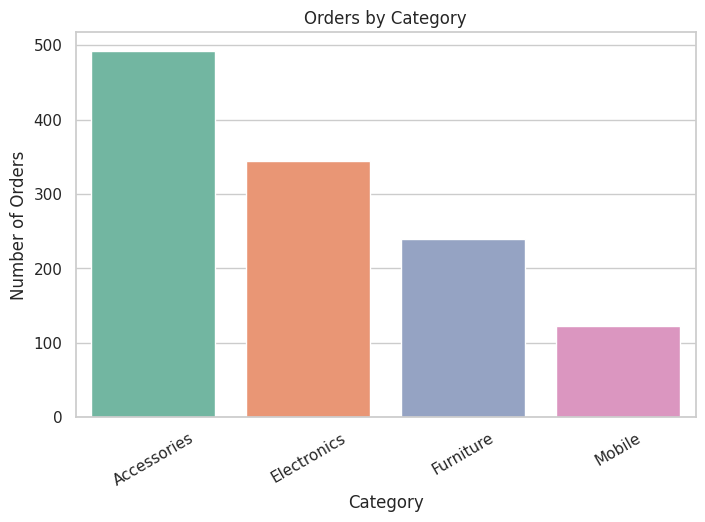

In [49]:
#2.Category distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="category",
    order=df["category"].value_counts().index,
    palette="Set2"
)

plt.title("Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.show()

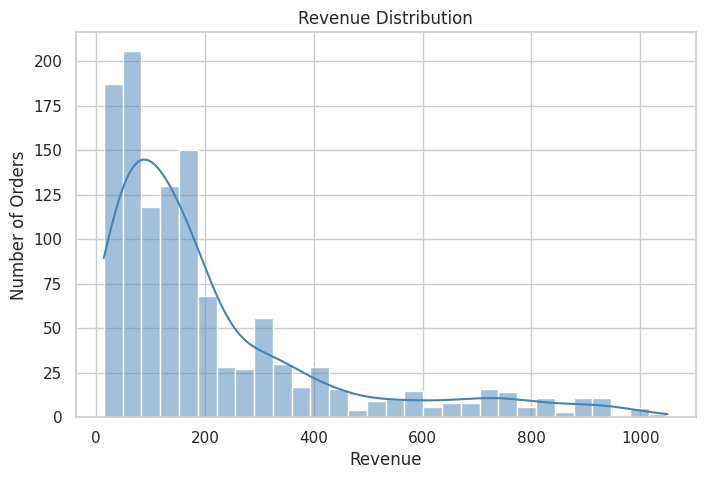

In [37]:
#3 revenue Distribution
plt.figure(figsize=(8, 5))

sns.histplot(df["revenue"], bins=30, kde=True, color="steelblue")

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Orders")
plt.show()

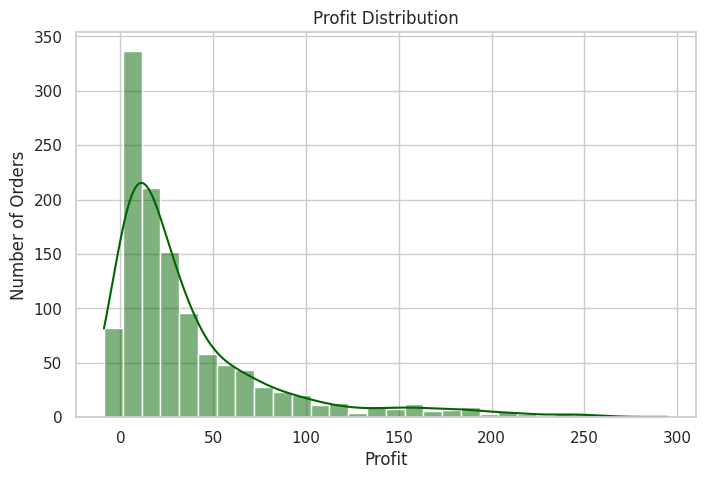

In [39]:
#4 profit Distribution
plt.figure(figsize=(8, 5))

sns.histplot(df["profit"], bins=30, kde=True, color="darkgreen")

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Number of Orders")
plt.show()

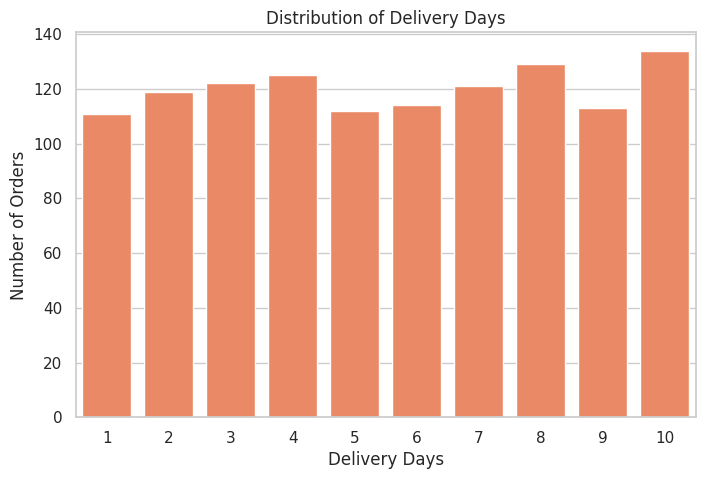

In [42]:
#Delivery Day Distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="delivery_days",
    color="coral"
)

plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.show()

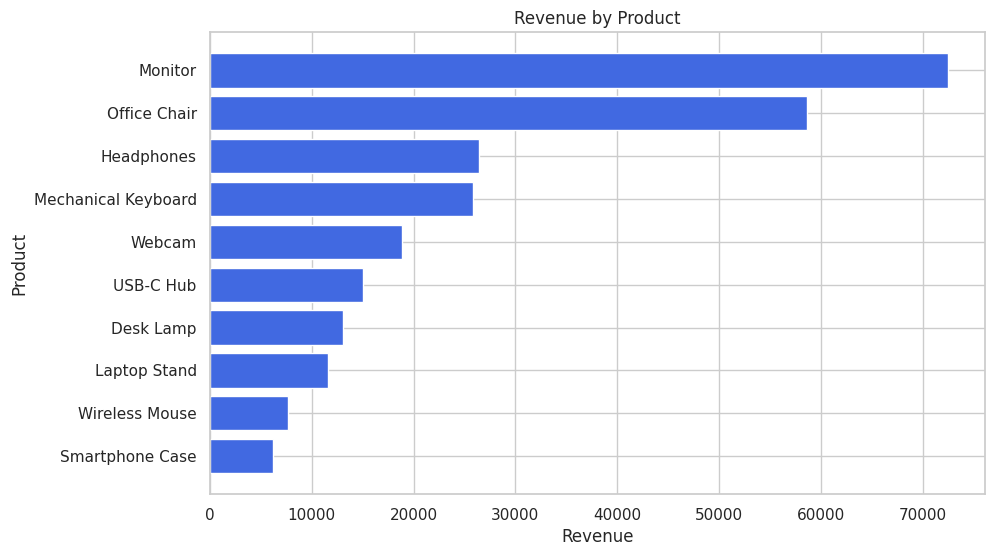

In [47]:
#Bivariate Analysis
#1.Revenue by product
plt.figure(figsize=(10, 6))

product_revenue = (
    df.groupby("product")["revenue"]
      .sum()
      .sort_values(ascending=True)
)

plt.barh(
    product_revenue.index,
    product_revenue.values,
    color="royalblue"
)

plt.title("Revenue by Product")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

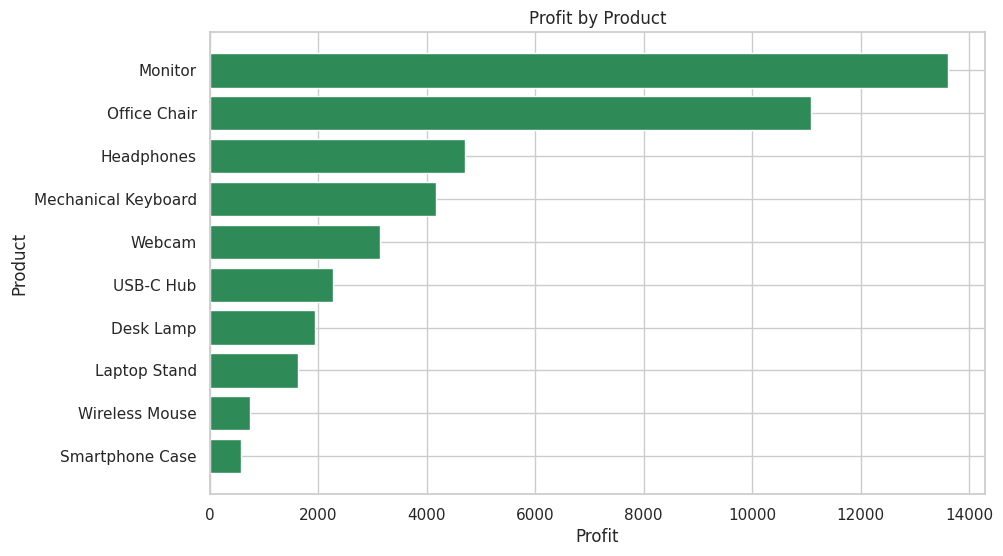

In [50]:
#2.Profit by product
plt.figure(figsize=(10, 6))

product_profit = (
    df.groupby("product")["profit"]
      .sum()
      .sort_values(ascending=True)
)

plt.barh(
    product_profit.index,
    product_profit.values,
    color="seagreen"
)

plt.title("Profit by Product")
plt.xlabel("Profit")
plt.ylabel("Product")
plt.show()


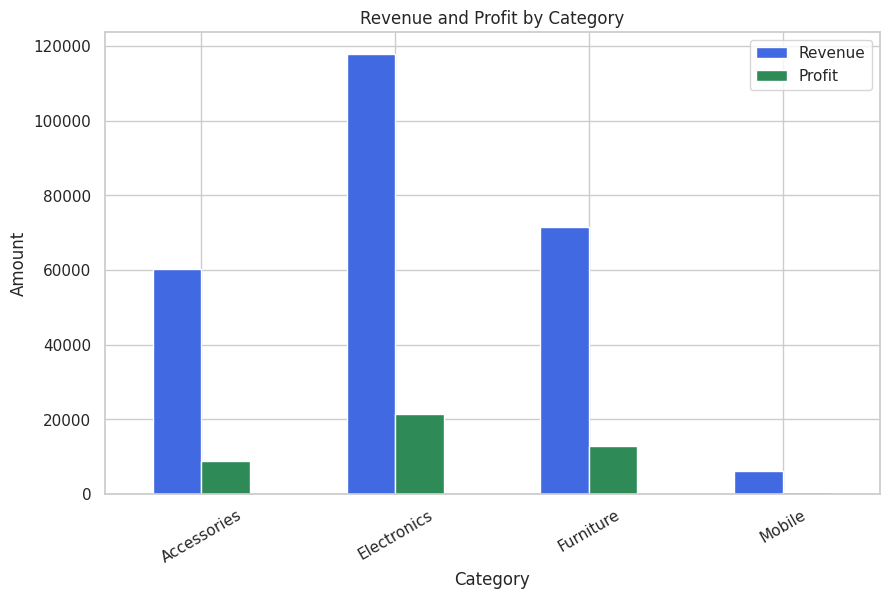

In [52]:
#3 Revenue and profit by category
category_summary = (
    df.groupby("category")
      .agg(
          revenue=("revenue", "sum"),
          profit=("profit", "sum")
      )
)

category_summary.plot(
    kind="bar",
    figsize=(10, 6),
    color=["royalblue", "seagreen"]
)

plt.title("Revenue and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=30)
plt.legend(["Revenue", "Profit"])
plt.show()

/tmp/ipykernel_1692/3044946068.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


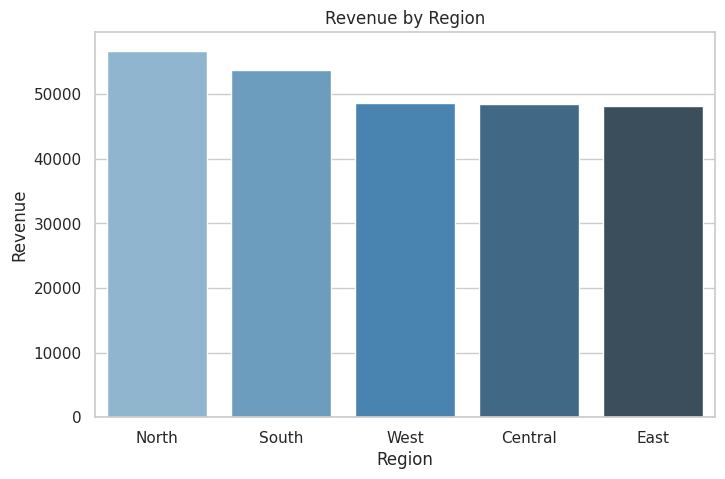

In [53]:
#4.Revenue by region
region_summary = (
    df.groupby("region")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=region_summary,
    x="region",
    y="revenue",
    palette="Blues_d"
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

/tmp/ipykernel_1692/3126650809.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


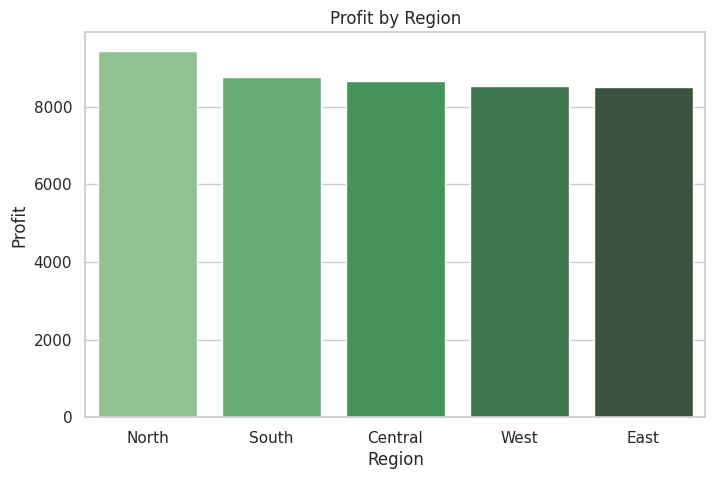

In [54]:
#5. Profit by region
region_profit = (
    df.groupby("region")["profit"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=region_profit,
    x="region",
    y="profit",
    palette="Greens_d"
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

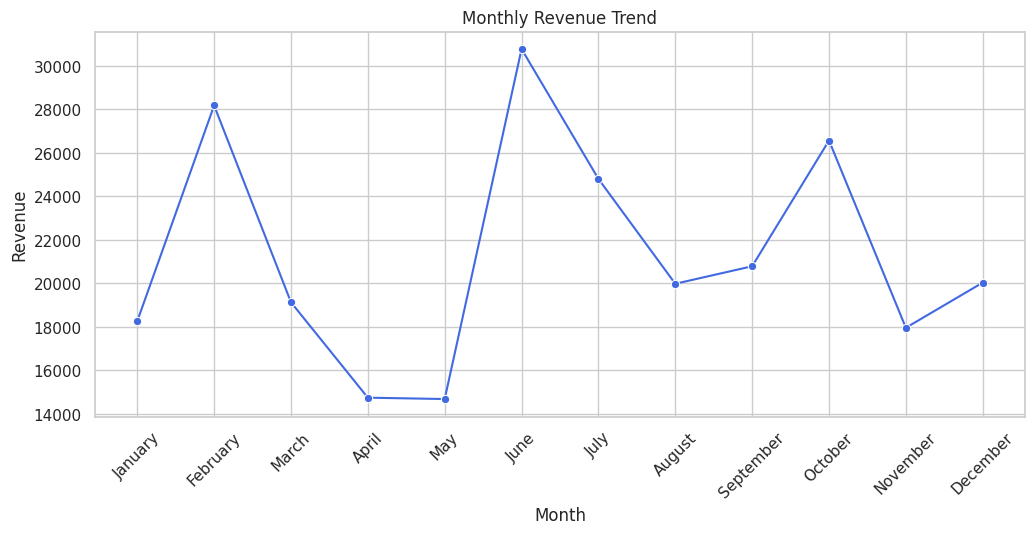

In [64]:
#6.Monthly revenue trend
monthly_summary = (
    df.groupby("month_name", observed=False)
      .agg(revenue=("revenue", "sum"))
      .reset_index()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_summary,
    x="month_name",
    y="revenue",
    marker="o",
    color="royalblue"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

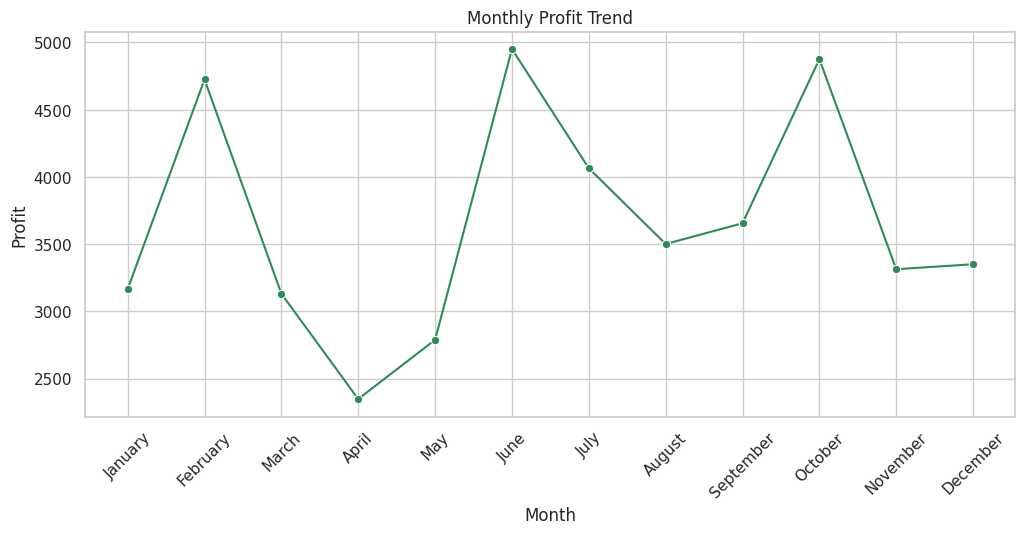

In [65]:
#Monthly profit trend
monthly_profit = (
    df.groupby("month_name", observed=False)
      .agg(profit=("profit", "sum"))
      .reset_index()
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_profit,
    x="month_name",
    y="profit",
    marker="o",
    color="seagreen"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_1692/3840747193.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


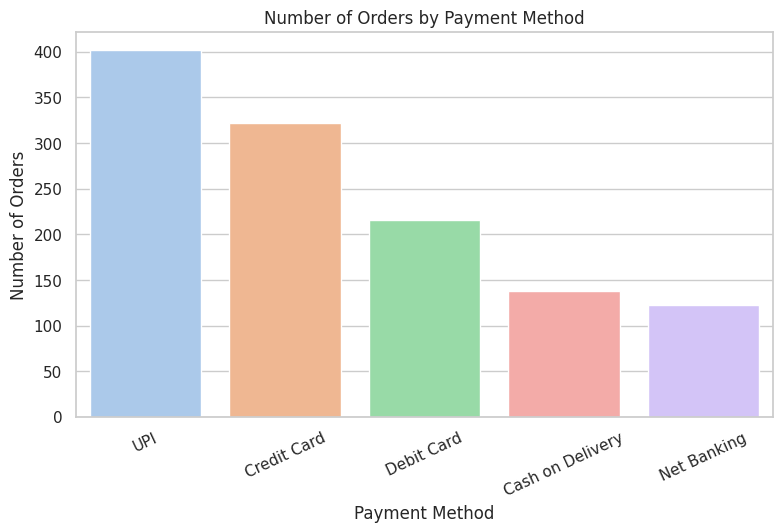

In [68]:
#Payment method versus number of orders
payment_counts = (
    df["payment_method"]
      .value_counts()
      .reset_index()
)

payment_counts.columns = ["payment_method", "orders"]

plt.figure(figsize=(9, 5))

sns.barplot(
    data=payment_counts,
    x="payment_method",
    y="orders",
    palette="pastel"
)

plt.title("Number of Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=25)
plt.show()

/tmp/ipykernel_1692/1697438852.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


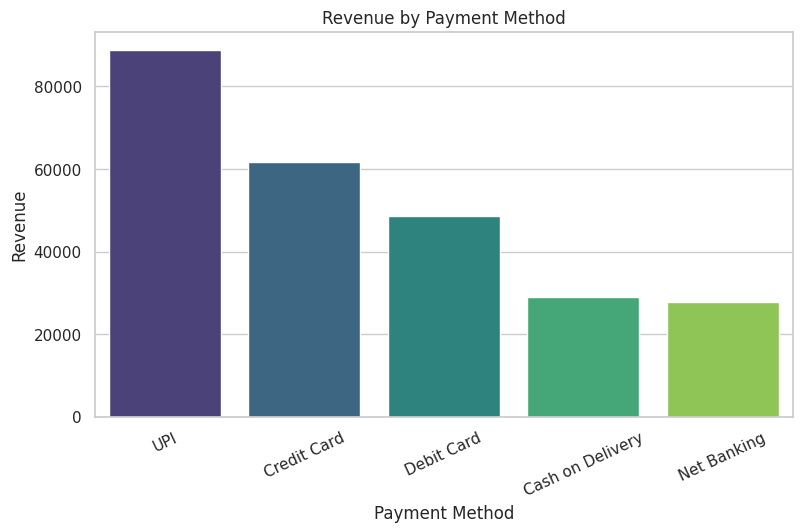

In [69]:
# Payment method versus revenue
payment_revenue = (
    df.groupby("payment_method")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=payment_revenue,
    x="payment_method",
    y="revenue",
    palette="viridis"
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.xticks(rotation=25)
plt.show()

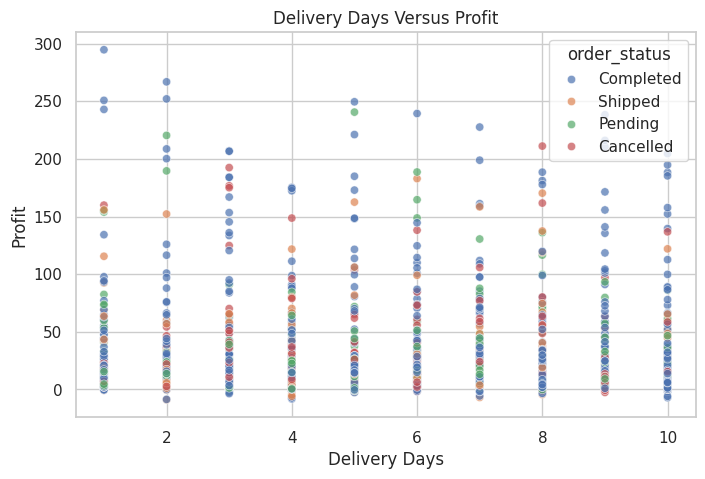

In [70]:
#Delivery Day vs Profit
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="delivery_days",
    y="profit",
    hue="order_status",
    alpha=0.7
)

plt.title("Delivery Days Versus Profit")
plt.xlabel("Delivery Days")
plt.ylabel("Profit")
plt.show()

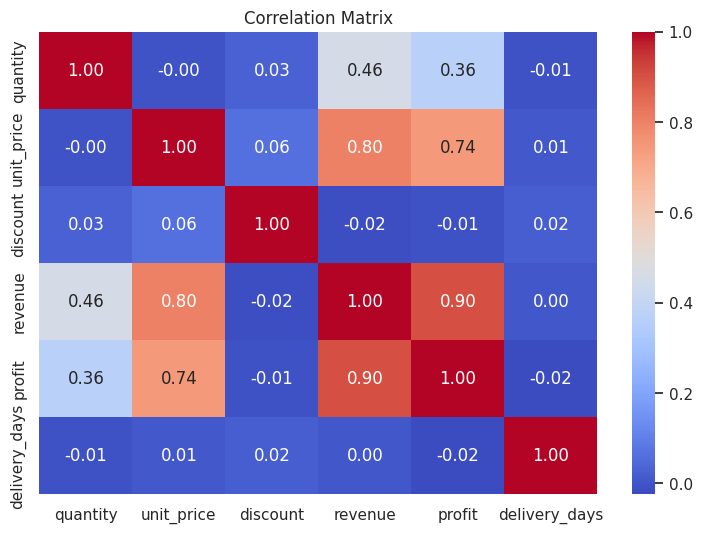

In [72]:
#Numerical correlation analysis
numeric_columns = [
    "quantity",
    "unit_price",
    "discount",
    "revenue",
    "profit",
    "delivery_days"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

/tmp/ipykernel_1692/916832211.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


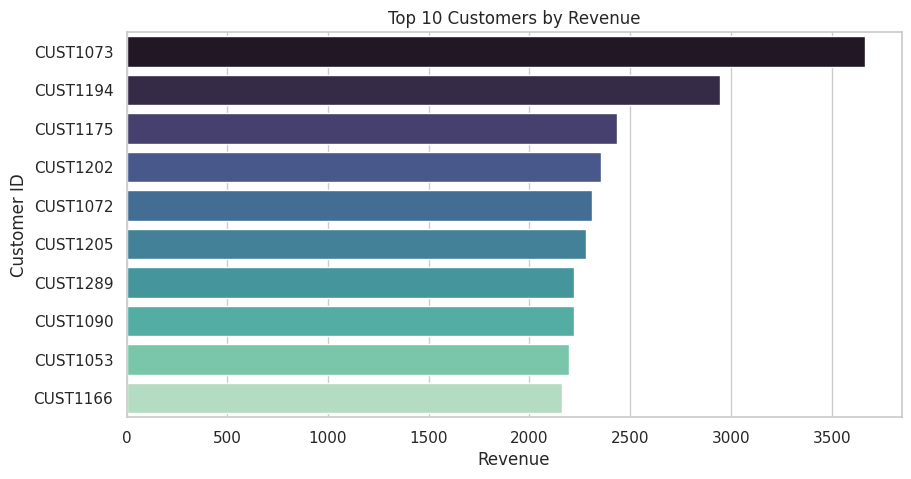

In [75]:
#Top Customers
customer_summary = (
    df.groupby("customer_id")
      .agg(
          orders=("order_id", "nunique"),
          quantity_sold=("quantity", "sum"),
          revenue=("revenue", "sum"),
          profit=("profit", "sum"),
          average_order_value=("revenue", "mean")
      )
      .sort_values("revenue", ascending=False)
)

customer_summary.head(10)
top_customers = customer_summary.head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_customers.reset_index(),
    x="revenue",
    y="customer_id",
    palette="mako"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.show()

In [76]:
repeat_customers = (
    customer_summary[customer_summary["orders"] > 1]
)

print("Total customers:", customer_summary.shape[0])
print("Repeat customers:", repeat_customers.shape[0])

Total customers: 291
Repeat customers: 265


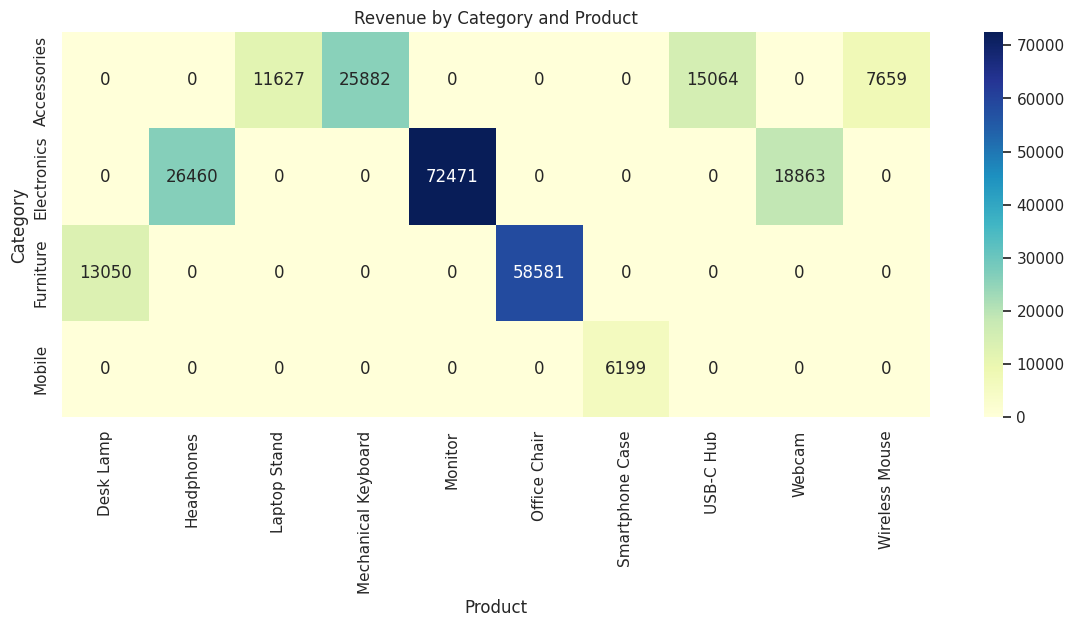

In [77]:
#Product-category heatmap
category_product_revenue = pd.pivot_table(
    df,
    values="revenue",
    index="category",
    columns="product",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(14, 5))

sns.heatmap(
    category_product_revenue,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Revenue by Category and Product")
plt.xlabel("Product")
plt.ylabel("Category")
plt.show()

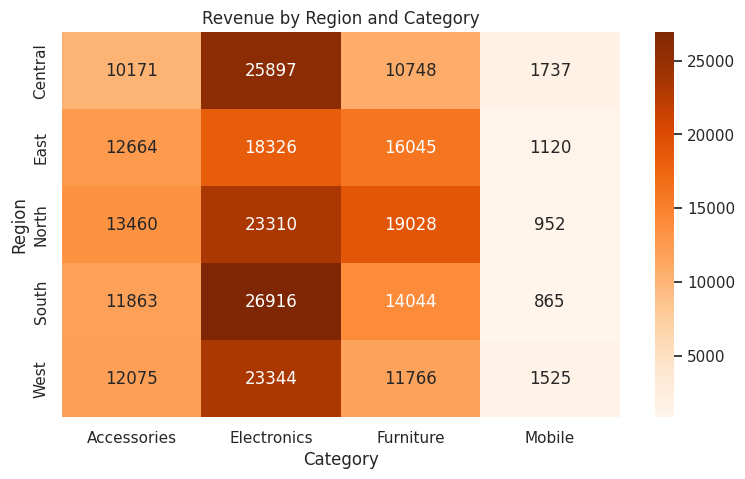

In [79]:
# Region-category analysis
region_category = pd.pivot_table(
    df,
    values="revenue",
    index="region",
    columns="category",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(9, 5))

sns.heatmap(
    region_category,
    annot=True,
    fmt=".0f",
    cmap="Oranges"
)

plt.title("Revenue by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")
plt.show()